<a href="https://colab.research.google.com/github/Janani-Hendeniya/230238R_EN2550_Assignment_01/blob/main/230238R_a01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 01**

In [173]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
im = cv2.imread("emma.jpg")
print(im.shape)

(810, 720, 3)


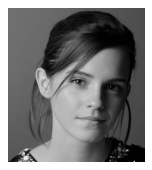

In [174]:
gray = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap = "gray")
plt.axis("off")
plt.show()

In [175]:
print(gray.shape)
print(gray.dtype)
print(gray.min())
print(gray.max())

(810, 720)
uint8
0
255


In [176]:
breakpoints = np.array([
    [0,0],
    [50,50],
    [50,100],
    [150,255],
    [150,150],
    [255,255]
])

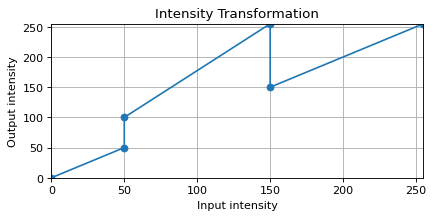

In [177]:
x = breakpoints[:,0]
y = breakpoints[:,1]
plt.figure(figsize=(6,2.5))
plt.plot(x,y,marker = "o")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid()
plt.show()

In [178]:
def intensity_transform(im, breakpoints):

    breakpoints = np.array(breakpoints)

    x_points = breakpoints[:, 0]
    y_points = breakpoints[:, 1]

    lut = np.interp(np.arange(256), x_points, y_points)

    lut = np.uint8(lut)

    transformed = lut[im]

    return transformed

In [179]:
transformed = intensity_transform(gray, breakpoints)

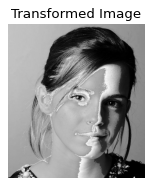

In [180]:
plt.figure(figsize=(6, 2.5))

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.show()

**Experimenting with intensity transformations**


**A) More visually pleasing output**

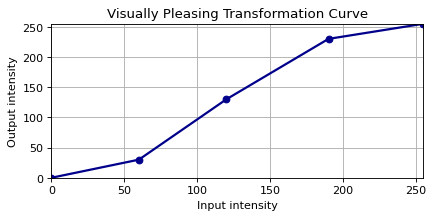

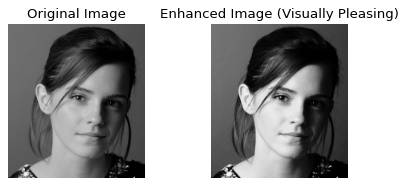

In [181]:
pleasing_breakpoints = np.array(
    [[0, 0], [60, 30], [120, 130], [190, 230], [255, 255]]
)

transformed = intensity_transform(gray, pleasing_breakpoints)

plt.figure(figsize = (6,2.5))
plt.plot(
    pleasing_breakpoints[:,0],
    pleasing_breakpoints[:,1],
    "o-",
    color="darkblue",
    linewidth=2,

)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Visually Pleasing Transformation Curve")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.show()

# Figure 2: Side-by-side image comparison
plt.figure(figsize=(6, 2.5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Enhanced Image (Visually Pleasing)")
plt.axis("off")

plt.show()

**B) Brightening Dark Areas**

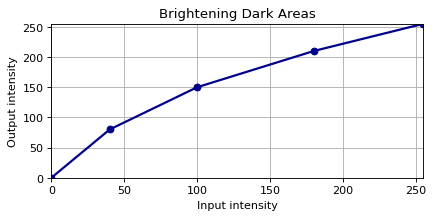

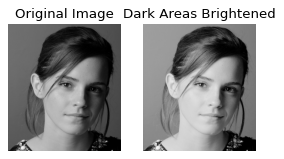

In [182]:
shadow_lift_breakpoints = np.array(
  [[0, 0], [40, 80], [100, 150], [180, 210], [255, 255]]
)

transformed = intensity_transform(gray, shadow_lift_breakpoints)

plt.figure(figsize = (6,2.5))
plt.plot(
    shadow_lift_breakpoints[:,0],
    shadow_lift_breakpoints[:,1],
    "o-",
    color="darkblue",
    linewidth=2,

)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Brightening Dark Areas")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.show()

# Figure 2: Side-by-side image comparison
plt.figure(figsize=(4,2.5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Dark Areas Brightened")
plt.axis("off")

plt.show()

**C) Posterization Effect**

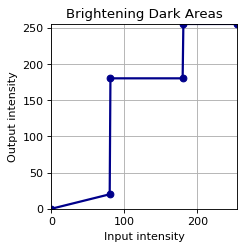

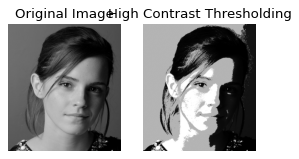

In [183]:
posterize_breakpoints = np.array(
  [[0, 0], [80, 20], [81, 180], [180, 180], [181, 255], [255, 255]]
)

transformed = intensity_transform(gray, posterize_breakpoints)

plt.figure(figsize = (3,3))
plt.plot(
    posterize_breakpoints[:,0],
    posterize_breakpoints[:,1],
    "o-",
    color="darkblue",
    linewidth=2,

)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Brightening Dark Areas")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.show()

# Figure 2: Side-by-side image comparison
plt.figure(figsize=(4, 2.5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("High Contrast Thresholding")
plt.axis("off")

plt.show()

**Question 02**

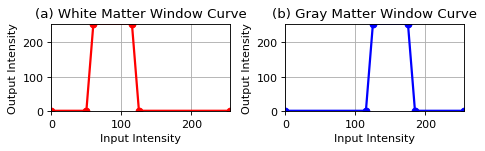

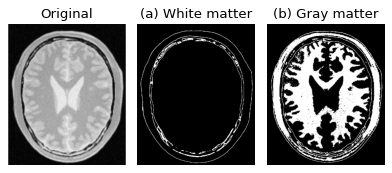

In [224]:
brain_image = cv2.imread("brain.png",cv2.IMREAD_GRAYSCALE)

#Elevating White Matter
breakpoints_wm = np.array(
    [[0, 0], [50, 0], [60, 255], [115, 255], [125, 0], [255, 0]]
    )
wm_accentuated = intensity_transform(brain_image, breakpoints_wm)

#elevating gray matter
breakpoints_gm = np.array(
    [[0, 0], [115, 0], [125, 255], [175, 255], [185, 0], [255, 0]]
)
gm_accentuated = intensity_transform(brain_image, breakpoints_gm)

#plotting the intensity transformation

fig, axes = plt.subplots(1, 2, figsize=(6, 2))

axes[0].plot(
    breakpoints_wm[:, 0], breakpoints_wm[:, 1], "r-o", linewidth=2
)
axes[0].set_title("(a) White Matter Window Curve")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True)

axes[1].plot(
    breakpoints_gm[:, 0], breakpoints_gm[:, 1], "b-o", linewidth=2
)
axes[1].set_title("(b) Gray Matter Window Curve")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#image results
fig, axes = plt.subplots(1, 3, figsize=(5, 15))

axes[0].imshow(brain_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(wm_accentuated, cmap="gray")
axes[1].set_title("(a) White matter")
axes[1].axis("off")

axes[2].imshow(gm_accentuated, cmap="gray")
axes[2].set_title("(b) Gray matter")
axes[2].axis("off")

plt.tight_layout()
plt.show()


**Question 03**

<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3080/429997567.py:26: SyntaxWarning: invalid escape sequence '\g'
  axes[0, 1].set_title(f"Gamma Corrected L* plane ($\gamma = {gamma}$)")
/tmp/ipykernel_3080/429997567.py:36: SyntaxWarning: invalid escape sequence '\g'
  axes[1, 1].set_title(f"Corrected L* Histogram ($\gamma = {gamma}$)")


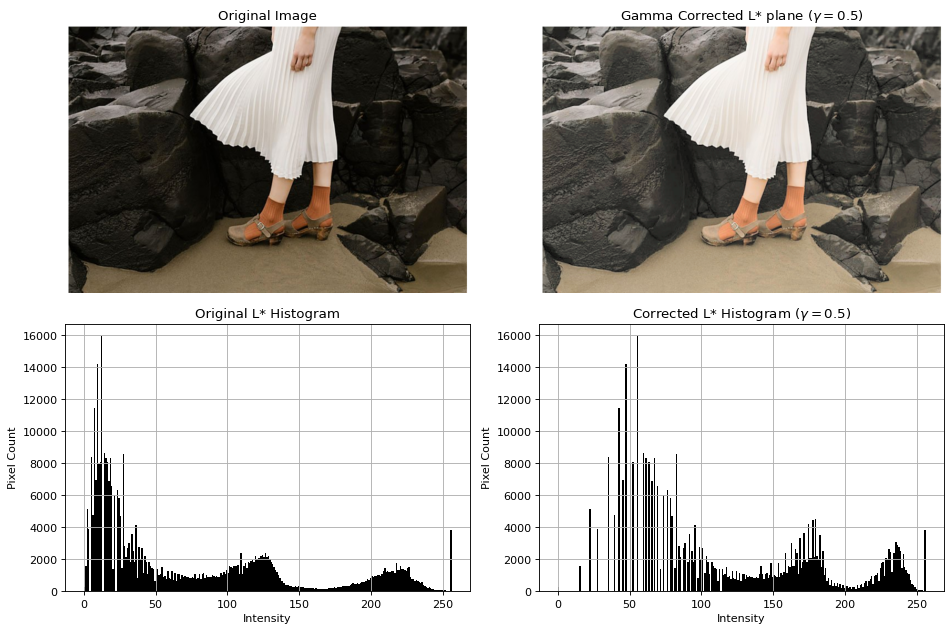

In [185]:
img_bgr = cv2.imread("problem3.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

#applying gamma correction to L* plane
#choosing gamma = 0.5 to brighten dark shadow regions
gamma = 0.5
L_normalized = L/255.0
L_gamma = np.uint8(np.power(L_normalized, gamma)*255)

#merging channels back together
lab_corrected = cv2.merge([L_gamma, a, b])
img_corrected_bgr = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
img_corrected_rgb = cv2.cvtColor(img_corrected_bgr, cv2.COLOR_BGR2RGB)

#display
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_corrected_rgb)
axes[0, 1].set_title(f"Gamma Corrected L* plane ($\gamma = {gamma}$)")
axes[0, 1].axis("off")

axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color="black")
axes[1, 0].set_title("Original L* Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].grid(True)

axes[1, 1].hist(L_gamma.ravel(), bins=256, range=[0, 256], color="black")
axes[1, 1].set_title(f"Corrected L* Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### Gamma Correction Justification

The image has a large contrast between the dark volcanic rocks and the bright white skirt. The \(L^*\) histogram is mainly concentrated in the lower intensity range, making details in the darker areas difficult to see.

I chose \(\gamma = 0.5\) because \(\gamma < 1\) increases the brightness of darker pixels more than brighter pixels. This helps reveal the texture and details in the rocks while keeping the already bright areas relatively less affected. The \(a^*\) and \(b^*\) channels were kept unchanged to preserve the original colour information.


**Question 04**\
a)Splitting the image into HSV planes

In [186]:
im_bgr = cv2.imread("spiderman.png")
im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
im_hsv = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2HSV)

# Split into individual H, S, V planes
H, S, V = cv2.split(im_hsv)

b)Applying intensity transformation to the saturation plane

In [187]:
a = 0.2
sigma = 70.0
x = np.arange(256, dtype=np.float32)
#transformation
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
lut = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

S_transformed = lut[S]


c)Adjust a to get a visually pleasing output and report a

When a = 0.5

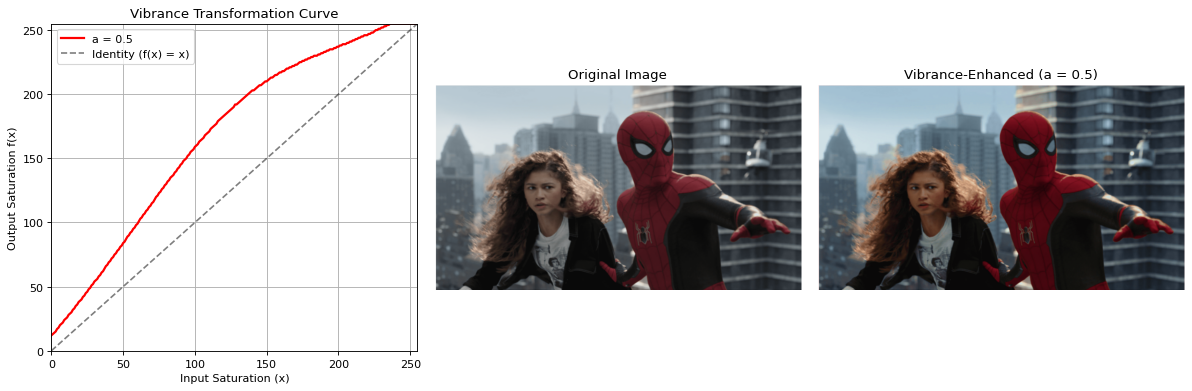

In [189]:
a = 0.5
sigma = 70.0
x = np.arange(256, dtype=np.float32)
#transformation
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
lut = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

S_transformed = lut[S]
hsv_transformed = cv2.merge([H, S_transformed, V])
img_vibrant_rgb = cv2.cvtColor(hsv_transformed, cv2.COLOR_HSV2RGB)
plt.figure(figsize=(15, 5))

# 1. Intensity Transformation Curve Plot
plt.subplot(1, 3, 1)
plt.plot(x, lut, "r-", linewidth=2, label=f"a = {a}")
plt.plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity (f(x) = x)")
plt.title("Vibrance Transformation Curve")
plt.xlabel("Input Saturation (x)")
plt.ylabel("Output Saturation f(x)")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.legend()

# 2. Original Image
plt.subplot(1, 3, 2)
plt.imshow(im_rgb)
plt.title("Original Image")
plt.axis("off")

# 3. Vibrance-Enhanced Image
plt.subplot(1, 3, 3)
plt.imshow(img_vibrant_rgb)
plt.title(f"Vibrance-Enhanced (a = {a})")
plt.axis("off")

plt.tight_layout()
plt.show()

**Choice of parameter: (a = 0.5)\**

I chose (a = 0.5) because it gives a good balance between enhancement and saturation. With (a = 0.2), the enhancement was too small and the image remained close to the original. On the other hand, (a = 0.8) caused too much saturation, resulting in loss of some shading and natural skin tones. Therefore, (a = 0.5) was selected as it enhances the mid-tone regions while keeping the image details and colours relatively natural.

**Question 05**

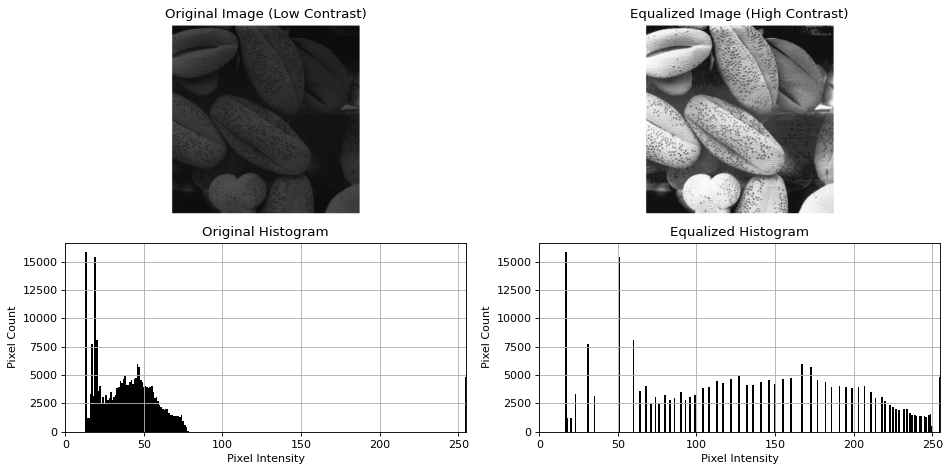

In [245]:
def custom_equalize_hist(img):
  hist, _ = np.histogram(img.ravel(), 256, [0, 256])
  pdf = hist / img.size
  cdf = np.cumsum(pdf)
  lut = np.round(cdf * 255).astype(np.uint8)
  equalized_img = lut[img]
  return equalized_img, hist
# Load pollen image in grayscale
img = cv2.imread("pollen.png", cv2.IMREAD_GRAYSCALE)

# Run custom histogram equalization
img_equalized, hist_original = custom_equalize_hist(img)

# Compute histogram of the equalized image for plotting
hist_equalized, _ = np.histogram(img_equalized.ravel(), 256, [0, 256])

# Display Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# 1. Original Image
axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original Image (Low Contrast)")
axes[0, 0].axis("off")

# 2. Equalized Image
axes[0, 1].imshow(img_equalized, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Equalized Image (High Contrast)")
axes[0, 1].axis("off")

# 3. Original Histogram
axes[1, 0].bar(range(256), hist_original, color="black", width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Pixel Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim(0, 255)
axes[1, 0].grid(True)

# 4. Equalized Histogram
axes[1, 1].bar(range(256), hist_equalized, color="black", width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()



**Question 06**

In [225]:
image = cv2.imread("jennifer.png")
plt.figure(figsize=(8,5))



<Figure size 640x400 with 0 Axes>

<Figure size 640x400 with 0 Axes>

a) Convering the image to HSV

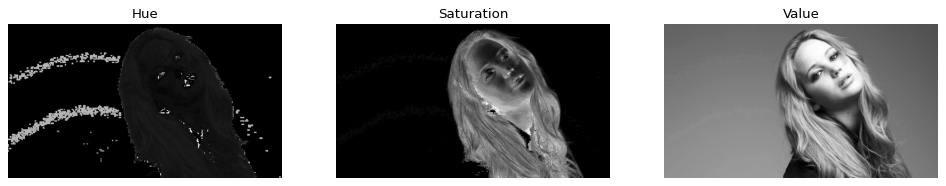

In [193]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
#displaying H,S and V in grayscale
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(H, cmap='gray')
plt.title("Hue")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(S, cmap='gray')
plt.title("Saturation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(V, cmap='gray')
plt.title("Value")
plt.axis("off")

plt.show()

b)
 saturation plane was selected for foreground extraction because the background is predominantly gray and therefore has low saturation, whereas the foreground contains regions with higher saturation. This provides better separation between the foreground and background compared with the hue and value planes.

c)

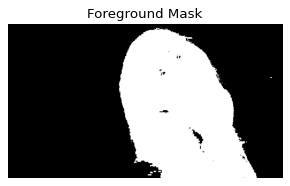

In [226]:
threshold = 11

_, mask = cv2.threshold(S, threshold, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(6,2.5))

plt.imshow(mask, cmap='gray')
plt.title("Foreground Mask")
plt.axis("off")

plt.show()

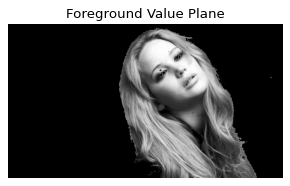

In [227]:
foreground = cv2.bitwise_and(V, V, mask=mask)
plt.figure(figsize=(7,2.5))

plt.imshow(foreground, cmap='gray')
plt.title("Foreground Value Plane")
plt.axis("off")

plt.show()

Calculating the histogram

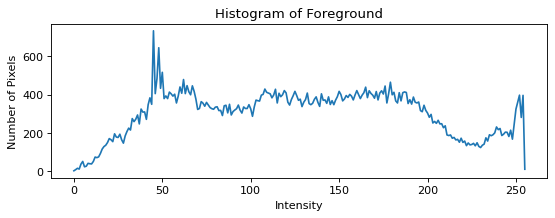

In [228]:
hist = cv2.calcHist([V], [0], mask, [256], [0,256])
plt.figure(figsize=(8,2.5))

plt.plot(hist)

plt.title("Histogram of Foreground")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.show()

d) Calculating the cumulative sum

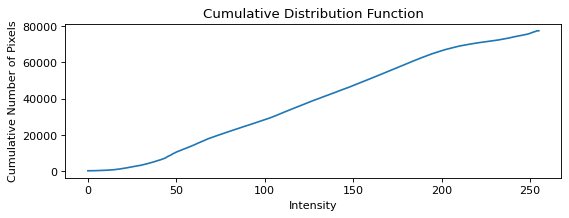

In [229]:
cdf = np.cumsum(hist)
plt.figure(figsize=(8,2.5))

plt.plot(cdf)

plt.title("Cumulative Distribution Function")
plt.xlabel("Intensity")
plt.ylabel("Cumulative Number of Pixels")

plt.show()

e) Histogram equalization

Number of foreground pixels: 77526


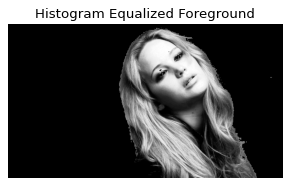

In [230]:
N = np.sum(mask > 0)
print("Number of foreground pixels:", N)
cdf_min = cdf[cdf > 0].min()
equalized_map = ((cdf - cdf_min) / (N - cdf_min) * 255)
equalized_map = np.clip(equalized_map, 0, 255)
equalized_map = equalized_map.astype(np.uint8)
equalized_foreground = equalized_map[V]
equalized_foreground = cv2.bitwise_and(
    equalized_foreground,
    equalized_foreground,
    mask=mask
)
plt.figure(figsize=(7,2.5))

plt.imshow(equalized_foreground, cmap='gray')
plt.title("Histogram Equalized Foreground")
plt.axis("off")

plt.show()

f)Extracting the background

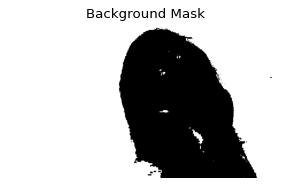

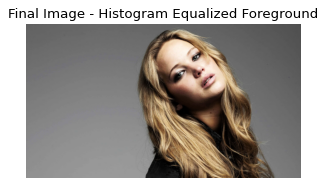

In [231]:
background_mask = cv2.bitwise_not(mask)
plt.figure(figsize=(7,2.5))

plt.imshow(background_mask, cmap='gray')
plt.title("Background Mask")
plt.axis("off")

plt.show()
background = cv2.bitwise_and(V, V, mask=background_mask)
result_V = cv2.add(background, equalized_foreground)
final_hsv = cv2.merge([H, S, result_V])
result = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
plt.figure(figsize=(7,2.5))

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Final Image - Histogram Equalized Foreground")
plt.axis("off")

plt.show()

**Question 07**

a)

In [201]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

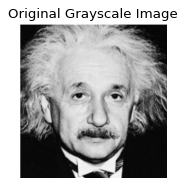

In [232]:
img = cv2.imread("einstein.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(6,2.5))
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


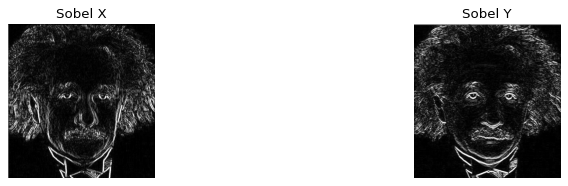

In [233]:
# Part (a) - Sobel filtering using cv2.filter2D

# Sobel X kernel
sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

# Sobel Y kernel
sobel_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# Apply Sobel X
gx = cv2.filter2D(gray, cv2.CV_32F, sobel_x)

# Apply Sobel Y
gy = cv2.filter2D(gray, cv2.CV_32F, sobel_y)

# Convert results to 8-bit images for display
gx_display = cv2.convertScaleAbs(gx)
gy_display = cv2.convertScaleAbs(gy)

# Display results
plt.figure(figsize=(12, 2.5))

plt.subplot(1, 2, 1)
plt.imshow(gx_display, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gy_display, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.show()

b)

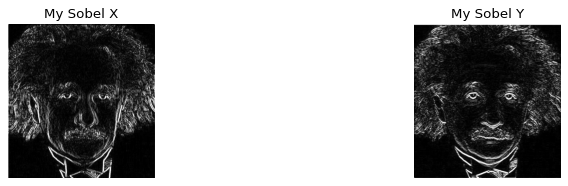

In [234]:
# Part (b) - Own Sobel filtering code

def my_filter(image, kernel):

    # Get image dimensions
    rows, cols = image.shape

    # Get kernel dimensions
    krows, kcols = kernel.shape

    # Calculate padding
    pad_r = krows // 2
    pad_c = kcols // 2

    # Pad the image with zeros
    padded = np.pad(
        image,
        ((pad_r, pad_r), (pad_c, pad_c)),
        mode="constant"
    )

    # Create output image
    output = np.zeros(
        (rows, cols),
        dtype=np.float32
    )

    # Move the kernel over every pixel
    for i in range(rows):

        for j in range(cols):

            # Extract current region
            region = padded[
                i:i+krows,
                j:j+kcols
            ]

            # Multiply and add
            output[i, j] = np.sum(
                region * kernel
            )

    return output


# Apply our own filter using Sobel X
gx_manual = my_filter(gray, sobel_x)

# Apply our own filter using Sobel Y
gy_manual = my_filter(gray, sobel_y)


# Convert results for display
gx_manual_display = cv2.convertScaleAbs(gx_manual)
gy_manual_display = cv2.convertScaleAbs(gy_manual)


# Display results
plt.figure(figsize=(12, 2.5))

plt.subplot(1, 2, 1)
plt.imshow(gx_manual_display, cmap="gray")
plt.title("My Sobel X")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gy_manual_display, cmap="gray")
plt.title("My Sobel Y")
plt.axis("off")

plt.show()

c)

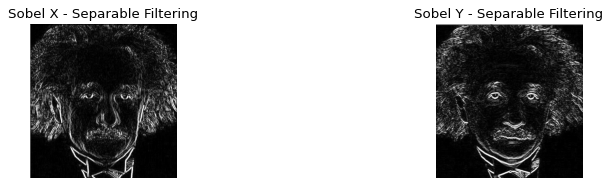

In [235]:
# Part (c) - Sobel filtering using separable filters
# 3 x 1 filter
vertical_smoothing = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

# 1 x 3 filter
horizontal_derivative = np.array([
    [1, 0, -1]
], dtype=np.float32)


# First filtering operation
temp_x = cv2.filter2D(
    gray,
    cv2.CV_32F,
    vertical_smoothing
)

# Second filtering operation
gx_separable = cv2.filter2D(
    temp_x,
    cv2.CV_32F,
    horizontal_derivative
)
# 3 x 1 filter
vertical_derivative = np.array([
    [1],
    [0],
    [-1]
], dtype=np.float32)

# 1 x 3 filter
horizontal_smoothing = np.array([
    [1, 2, 1]
], dtype=np.float32)


# First filtering operation
temp_y = cv2.filter2D(
    gray,
    cv2.CV_32F,
    horizontal_smoothing
)

# Second filtering operation
gy_separable = cv2.filter2D(
    temp_y,
    cv2.CV_32F,
    vertical_derivative
)


# Convert results for display
gx_sep_display = cv2.convertScaleAbs(gx_separable)
gy_sep_display = cv2.convertScaleAbs(gy_separable)


# Display results
plt.figure(figsize=(12, 2.5))

plt.subplot(1, 2, 1)
plt.imshow(gx_sep_display, cmap="gray")
plt.title("Sobel X - Separable Filtering")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gy_sep_display, cmap="gray")
plt.title("Sobel Y - Separable Filtering")
plt.axis("off")

plt.show()

**Question 08**

Large image shape: (112, 200)
Small image shape: (28, 50)


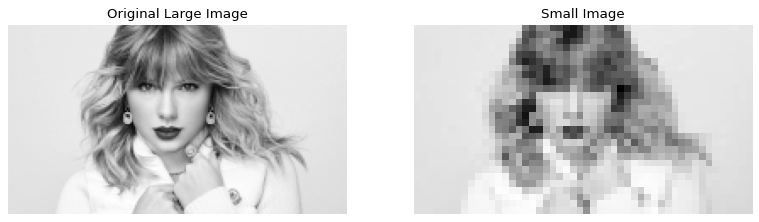

In [206]:
large = cv2.imread("large.jpg", cv2.IMREAD_GRAYSCALE)
small = cv2.imread("small.jpg", cv2.IMREAD_GRAYSCALE)

print("Large image shape:", large.shape)
print("Small image shape:", small.shape)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(large, cmap='gray')
plt.title("Original Large Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(small, cmap='gray')
plt.title("Small Image")
plt.axis("off")

plt.show()

In [207]:
def zoom_image(image, scale, method):

    if scale <= 0 or scale > 10:
        raise ValueError("Scale factor must be between 0 and 10.")

    height, width = image.shape

    new_height = int(height * scale)
    new_width = int(width * scale)

    zoomed = np.zeros((new_height, new_width), dtype=np.uint8)

    for y in range(new_height):
        for x in range(new_width):

            # Find corresponding position in original image
            src_y = y / scale
            src_x = x / scale

            if method == "nearest":

                # Nearest-neighbor interpolation
                y_nearest = int(round(src_y))
                x_nearest = int(round(src_x))

                # Prevent going outside image boundaries
                y_nearest = min(y_nearest, height - 1)
                x_nearest = min(x_nearest, width - 1)

                zoomed[y, x] = image[y_nearest, x_nearest]

            elif method == "bilinear":

                # Four neighboring pixels
                y1 = int(np.floor(src_y))
                x1 = int(np.floor(src_x))

                y2 = min(y1 + 1, height - 1)
                x2 = min(x1 + 1, width - 1)

                # Fractional distances
                dy = src_y - y1
                dx = src_x - x1

                # Pixel values
                I11 = image[y1, x1]
                I12 = image[y1, x2]
                I21 = image[y2, x1]
                I22 = image[y2, x2]

                # Bilinear interpolation
                value = (
                    I11 * (1 - dx) * (1 - dy) +
                    I12 * dx * (1 - dy) +
                    I21 * (1 - dx) * dy +
                    I22 * dx * dy
                )

                zoomed[y, x] = np.clip(value, 0, 255)

            else:
                raise ValueError("Method must be 'nearest' or 'bilinear'")

    return zoomed

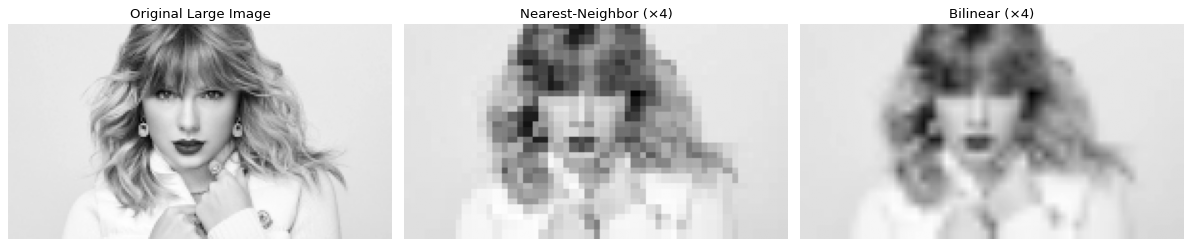

In [208]:
#zooming the image by factor 4

nearest = zoom_image(small, 4, "nearest")

bilinear = zoom_image(small, 4, "bilinear")

#Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(large, cmap='gray')
plt.title("Original Large Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(nearest, cmap='gray')
plt.title("Nearest-Neighbor (×4)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilinear, cmap='gray')
plt.title("Bilinear (×4)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [209]:
#calculate the normalized SSD
def normalized_ssd(original, reconstructed):

    if original.shape != reconstructed.shape:
        raise ValueError("Images must have the same dimensions.")

    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)

    ssd = np.sum((original - reconstructed) ** 2)

    normalization = np.sum(original ** 2)

    return ssd / normalization

#calculate the NSSD for both methods
nssd_nearest = normalized_ssd(large, nearest)

nssd_bilinear = normalized_ssd(large, bilinear)

print("Nearest-neighbor normalized SSD:", nssd_nearest)
print("Bilinear normalized SSD:", nssd_bilinear)

Nearest-neighbor normalized SSD: 0.009313001844030574
Bilinear normalized SSD: 0.007509603610471512


**Question 09**

a)

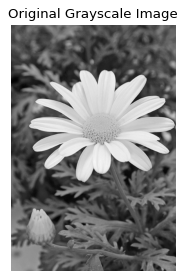

Image shape: (662, 442, 3)


In [236]:
img = cv2.imread("flower.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(6,4))
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print("Image shape:", img.shape)

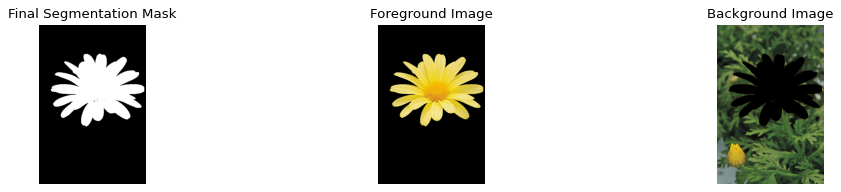

In [237]:
plt.figure(figsize=(15, 2.5))

plt.subplot(1, 3, 1)
plt.imshow(binary_mask, cmap="gray")
plt.title("Final Segmentation Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(foreground_rgb)
plt.title("Foreground Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(background_rgb)
plt.title("Background Image")
plt.axis("off")

plt.tight_layout()
plt.show()

b)

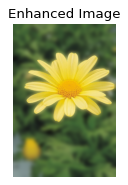

In [239]:
# Strong Gaussian blur
blurred_background = cv2.GaussianBlur(
    img,
    (51, 51),
    0
)
# Convert the binary mask into a 3-channel mask
mask_3channel = cv2.merge([
    binary_mask,
    binary_mask,
    binary_mask
])

# Keep the flower sharp and use the blurred image for the background
enhanced = np.where(
    mask_3channel == 1,
    img,
    blurred_background
).astype(np.uint8)
enhanced_rgb = cv2.cvtColor(
    enhanced,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(3, 3))

plt.subplot(1, 2, 2)
plt.imshow(enhanced_rgb)
plt.title("Enhanced Image")
plt.axis("off")

plt.tight_layout()
plt.show()

### c) Reason for the Dark Region

The dark region just outside the flower is caused by inaccuracies in the GrabCut segmentation near the boundary of the flower. Some boundary pixels may be classified as background. When the background is strongly blurred using Gaussian filtering, the dark green pixels surrounding the flower spread into neighbouring pixels. These incorrectly classified and blurred boundary pixels therefore produce a dark halo around the edge of the flower.

**Question 10**

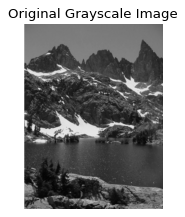

In [240]:
img = cv2.imread("Q10.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(3,3))
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

a)

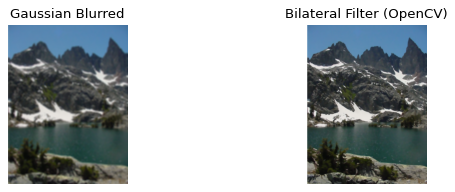

In [241]:
d = 9
sigmaColor = 50
sigmaSpace = 10
gaussian = cv2.GaussianBlur(
    img,
    (9, 9),
    sigmaX=sigmaSpace
)

gaussian_rgb = cv2.cvtColor(
    gaussian,
    cv2.COLOR_BGR2RGB
)
bilateral_opencv = cv2.bilateralFilter(
    img,
    d,
    sigmaColor,
    sigmaSpace
)

bilateral_opencv_rgb = cv2.cvtColor(
    bilateral_opencv,
    cv2.COLOR_BGR2RGB
)
plt.figure(figsize=(12, 2.5))


plt.subplot(1, 3, 2)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral_opencv_rgb)
plt.title("Bilateral Filter (OpenCV)")
plt.axis("off")

plt.tight_layout()
plt.show()

b)

In [215]:
def bilateral_filter(image, d, sigma_color, sigma_space):

    if d % 2 == 0:
        d += 1

    radius = d // 2

    padded = cv2.copyMakeBorder(
        image,
        radius,
        radius,
        radius,
        radius,
        cv2.BORDER_REFLECT
    )

    output = np.zeros_like(image, dtype=np.float32)

    x, y = np.meshgrid(
        np.arange(-radius, radius + 1),
        np.arange(-radius, radius + 1)
    )

    spatial_weights = np.exp(
        -(x**2 + y**2) / (2 * sigma_space**2)
    )

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            neighbourhood = padded[
                i:i+d,
                j:j+d
            ].astype(np.float32)

            center = padded[
                i+radius,
                j+radius
            ].astype(np.float32)

            color_difference = neighbourhood - center

            color_distance = np.sqrt(
                np.sum(color_difference**2, axis=2)
            )

            range_weights = np.exp(
                -(color_distance**2) /
                (2 * sigma_color**2)
            )

            weights = spatial_weights * range_weights

            weight_sum = np.sum(weights)

            output[i, j] = np.sum(
                neighbourhood * weights[:, :, np.newaxis],
                axis=(0, 1)
            ) / weight_sum

    return np.clip(output, 0, 255).astype(np.uint8)

In [216]:
bilateral_own = bilateral_filter(
    img,
    d=9,
    sigma_color=50,
    sigma_space=10
)

bilateral_own_rgb = cv2.cvtColor(
    bilateral_own,
    cv2.COLOR_BGR2RGB
)

In [217]:
opencv_float = bilateral_opencv.astype(np.float64)
own_float = bilateral_own.astype(np.float64)

mse = np.mean(
    (opencv_float - own_float) ** 2
)

if mse == 0:
    psnr = float("inf")
else:
    psnr = 10 * np.log10(
        (255 ** 2) / mse
    )

print("Mean Squared Error (MSE):", mse)
print("Peak Signal-to-Noise Ratio (PSNR):", psnr, "dB")

Mean Squared Error (MSE): 11.418254362712613
Peak Signal-to-Noise Ratio (PSNR): 37.554806473774846 dB


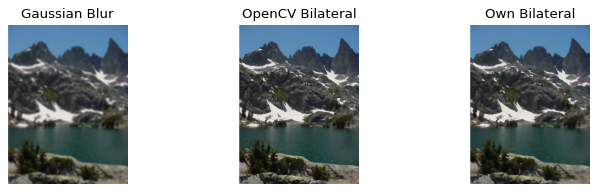

In [242]:
plt.figure(figsize=(12, 2.5))

plt.subplot(1, 4, 2)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(bilateral_opencv_rgb)
plt.title("OpenCV Bilateral")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(bilateral_own_rgb)
plt.title("Own Bilateral")
plt.axis("off")

plt.tight_layout()
plt.show()

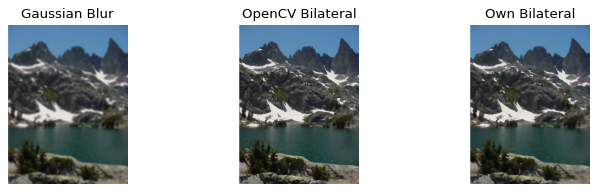

In [243]:
plt.figure(figsize=(12, 2.5))
plt.subplot(1, 4, 2)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(bilateral_opencv_rgb)
plt.title("OpenCV Bilateral")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(bilateral_own_rgb)
plt.title("Own Bilateral")
plt.axis("off")

plt.tight_layout()
plt.show()